In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dl = DataLoader(
    datasets.ImageFolder('data/Training', tf),
    batch_size=32, shuffle=True, num_workers=4, pin_memory=True
)

test_dl = DataLoader(
    datasets.ImageFolder('data/Testing', tf),
    batch_size=32, shuffle=False, num_workers=4, pin_memory=True
)

In [2]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 4) #4 Classes
).to(device)

In [3]:
opt = optim.AdamW(model.parameters(), 1e-4)
loss_fn = nn.CrossEntropyLoss()

In [4]:
model.train()

for epoch in range(25):
    running_loss = 0

    for x, y in train_dl:
        opt.zero_grad()

        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward()
        
        running_loss += loss

        opt.step()

    print(f"Epoch {epoch+1}: Loss was {running_loss}")

C:\Users\SHC\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1: Loss was 152.30023193359375
Epoch 2: Loss was 106.8170394897461
Epoch 3: Loss was 89.57954406738281
Epoch 4: Loss was 80.86555480957031
Epoch 5: Loss was 73.23247528076172
Epoch 6: Loss was 64.8946533203125
Epoch 7: Loss was 59.54861831665039
Epoch 8: Loss was 52.258941650390625
Epoch 9: Loss was 47.39281463623047
Epoch 10: Loss was 43.687530517578125
Epoch 11: Loss was 38.11353302001953
Epoch 12: Loss was 33.790199279785156
Epoch 13: Loss was 31.620176315307617
Epoch 14: Loss was 29.676788330078125
Epoch 15: Loss was 25.717491149902344
Epoch 16: Loss was 21.99149513244629
Epoch 17: Loss was 20.878997802734375
Epoch 18: Loss was 18.59646987915039
Epoch 19: Loss was 17.427541732788086
Epoch 20: Loss was 15.931426048278809
Epoch 21: Loss was 13.181717872619629
Epoch 22: Loss was 12.475213050842285
Epoch 23: Loss was 12.06643295288086
Epoch 24: Loss was 11.102307319641113
Epoch 25: Loss was 9.008675575256348


In [7]:
model.eval()
test_loss, correct = 0.0, 0

with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        test_loss += loss_fn(logits, y).item() * y.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()

test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct / len(test_dl.dataset)

print('Test Loss: ', test_loss, 'Test Accuracy: ', accuracy, '%')

Test Loss:  1.292462841066299 Test Accuracy:  89.875 %


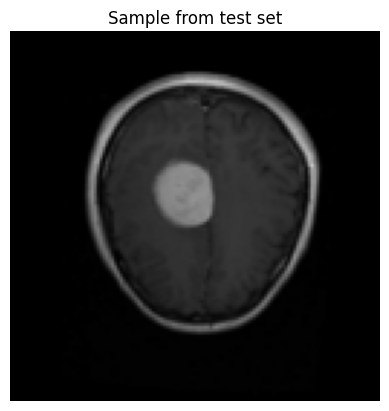

Predicted class: glioma
Ground-truth: meningioma


In [14]:
import random
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

model.eval()

idx = random.randint(0, len(test_dl.dataset) - 1)
img, label = test_dl.dataset[idx]

unnorm = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title('Sample from test set')
plt.show()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(1).item()

class_names = test_dl.dataset.classes
print(f"Predicted class: {class_names[pred]}")
print(f"Ground-truth: {class_names[label]}")